### [12-Month Time-Series Momentum Strategy](https://wire.insiderfinance.io/building-a-12-month-time-series-momentum-strategy-to-reduce-drawdowns-a3f00a2fdac5)

> Long-term trend following with volatility targeting to reduce drawdowns

In [1]:
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules or "google.colab" in str(get_ipython())

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

plt.style.use('ggplot')
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
ticker = "SPY"  # S&P 500 ETF
start_date = "2000-01-01"

data = yf.download(ticker, start=start_date, auto_adjust=True, progress=False, multi_level_index=False)
if data.empty:
    print("No data found for the specified ticker and date range.")
else:
  weekly = data.resample("W-FRI").last()
  display(weekly.head())

,Close,High,Low,Open,Volume
Date,,,,,
2000-01-07,91.813904,91.813904,88.231114,88.388600,8066500
2000-01-14,92.581680,92.896651,91.951739,92.306081,7437300
2000-01-21,90.987091,91.656403,90.750863,91.656403,6244800
2000-01-28,85.593216,88.231093,85.376674,87.837380,11916200
2000-02-04,89.825630,90.711485,89.530345,90.199658,4925400


##### **Establishing a Price Baseline**

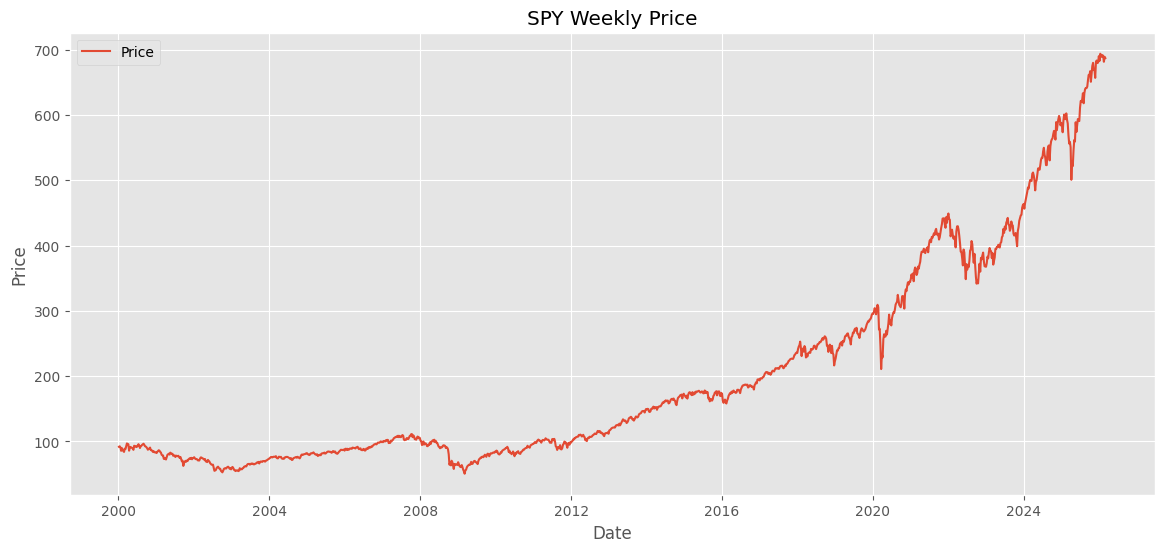

In [3]:
plt.plot(weekly.index, weekly["Close"], label="Price")
plt.title(f"{ticker} Weekly Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
if not IN_COLAB:
  plt.savefig("spy_weekly_price.png")
plt.show()

##### **Calculating 12-Month Momentum**

In [4]:
lookback = 52
weekly["Momentum"] = weekly["Close"].pct_change(lookback)
weekly[["Close", "Momentum"]].dropna().head()

,Close,Momentum
Date,,
2001-01-05,82.236351,-0.104315
2001-01-12,84.026718,-0.092404
2001-01-19,85.309753,-0.062397
2001-01-26,86.493423,0.010517
2001-02-02,85.809120,-0.044715


##### **Generating the Trading Signal**

In [5]:
weekly["Signal"] = np.where(weekly["Momentum"] > 0, 1, 0)
weekly["Signal"] = weekly["Signal"].shift(1)  # avoid lookahead bias

display(weekly.sample(15))

,Close,High,Low,Open,Volume,Momentum,Signal
Date,,,,,,,
2020-10-23,321.407440,321.602630,318.944233,321.546862,49143900,0.168656,1.0
2017-11-10,226.624023,226.799650,225.991804,226.307927,59984700,0.216673,1.0
2005-04-29,78.827904,78.909628,77.615691,78.364811,103993800,0.063593,1.0
2017-04-07,204.507584,205.203190,204.020663,204.464106,74412300,0.173877,1.0
2017-12-29,235.522491,237.014036,235.328352,236.996394,96007400,0.217054,1.0
2008-02-08,95.285835,96.109298,94.591258,95.300149,221643500,-0.058457,0.0
2010-10-08,88.686363,88.929881,87.978638,88.313477,177760100,0.107985,1.0
2005-12-30,85.951492,86.331164,85.847944,86.151685,44645600,0.048283,1.0
2020-09-04,317.154144,322.023877,310.025409,320.450019,139156300,0.172315,1.0


##### **Applying Volatility Targeting**

In [6]:
target_vol = 0.10  # 10% annual volatility
weekly["Returns"] = weekly["Close"].pct_change()

rolling_vol = weekly["Returns"].rolling(52).std() * np.sqrt(52)
weekly["Position"] = (target_vol / rolling_vol) * weekly["Signal"]
weekly["Position"] = weekly["Position"].clip(0, 1)

display(weekly[["Signal", "Position"]].dropna().head())

,Signal,Position
Date,,
2001-01-05,0.0,0.000000
2001-01-12,0.0,0.000000
2001-01-19,0.0,0.000000
2001-01-26,0.0,0.000000
2001-02-02,1.0,0.486974


##### **Calculating Strategy and Benchmark Returns**

In [7]:
weekly["Strategy_Returns"] = weekly["Position"] * weekly["Returns"]
weekly["Cumulative_Strategy"] = (1 + weekly["Strategy_Returns"]).cumprod()
weekly["Cumulative_BuyHold"] = (1 + weekly["Returns"]).cumprod()

display(weekly[["Strategy_Returns", "Cumulative_Strategy", "Cumulative_BuyHold"]].head())

,Strategy_Returns,Cumulative_Strategy,Cumulative_BuyHold
Date,,,
2000-01-07,NaN,NaN,NaN
2000-01-14,NaN,NaN,1.008362
2000-01-21,NaN,NaN,0.990995
2000-01-28,NaN,NaN,0.932247
2000-02-04,NaN,NaN,0.978345


##### **Removing Warm-Up Periods**

In [8]:
weekly_clean = weekly.dropna().copy()
display(weekly_clean.sample(15))

,Close,High,Low,Open,Volume,Momentum,Signal,Returns,Position,Strategy_Returns,Cumulative_Strategy,Cumulative_BuyHold
Date,,,,,,,,,,,,
2006-06-02,89.405144,89.703156,88.933866,89.578410,91702600,0.092647,1.0,0.004830,1.000000,0.004830,1.259331,0.973765
2017-01-20,196.297577,196.791041,195.630954,196.262940,129168600,0.215668,1.0,-0.001366,0.966294,-0.001320,2.289386,2.137994
2016-06-24,174.042542,180.559289,173.597241,174.376514,333444400,-0.010358,1.0,-0.015883,0.663668,-0.010541,2.141229,1.895601
2024-07-12,549.946838,553.560832,547.157806,547.629178,53084400,0.263851,1.0,0.009646,0.848470,0.008184,4.061839,5.989799
2004-02-06,76.178780,76.345181,75.346770,75.493205,37216000,0.394345,1.0,0.008548,0.796019,0.006804,1.081342,0.829709
2005-07-01,81.730698,81.915318,81.511892,81.675995,49737500,0.080059,1.0,0.004623,0.912667,0.004219,1.154181,0.890178
2024-12-13,595.193848,598.070258,593.814715,597.351170,35904700,0.299528,1.0,-0.005923,0.826554,-0.004896,4.320240,6.482611
2023-06-09,414.825073,416.841782,413.831193,414.882967,85742800,0.121558,1.0,0.004627,0.497970,0.002304,3.291040,4.518107
2010-03-12,86.626045,87.008684,86.385959,86.993675,162074800,0.552542,1.0,0.010591,0.547223,0.005796,1.480756,0.943496


In [9]:
display(weekly_clean.describe())

,Close,High,Low,Open,Volume,Momentum,Signal,Returns,Position,Strategy_Returns,Cumulative_Strategy,Cumulative_BuyHold
count,1313.000000,1313.000000,1313.000000,1313.000000,1.313000e+03,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000
mean,204.111846,205.216987,202.822338,204.072312,1.138562e+08,0.094515,0.768469,0.001907,0.575990,0.001209,2.148051,2.223104
std,159.190455,159.932757,158.239116,159.082284,9.129913e+07,0.169687,0.421971,0.024383,0.360236,0.011808,0.983748,1.733838
min,50.538567,51.660504,49.203973,50.890550,6.434900e+06,-0.455872,0.000000,-0.197934,0.000000,-0.069587,0.974101,0.550446
25%,84.021309,84.575163,83.596147,84.411056,5.705360e+07,0.012703,1.000000,-0.009638,0.331176,-0.002283,1.426230,0.915126
50%,134.322311,134.612544,133.637083,134.265887,8.912760e+07,0.128122,1.000000,0.003166,0.654978,0.000000,1.833266,1.462984
75%,270.536560,272.370022,268.684841,270.162747,1.405534e+08,0.193322,1.000000,0.014856,0.892911,0.007466,2.946931,2.946575
max,694.070007,695.309998,690.099976,693.659973,8.710263e+08,0.729572,1.000000,0.132922,1.000000,0.045002,4.481381,7.559531


##### **Comparing Long-Term Growth**

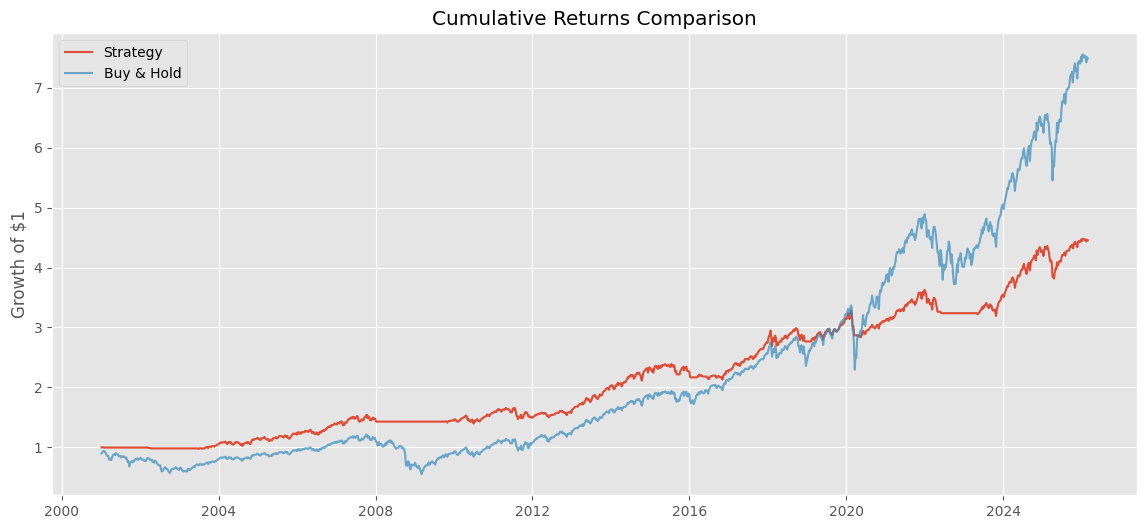

In [10]:
plt.plot(
    weekly_clean.index,
    weekly_clean["Cumulative_Strategy"],
    label="Strategy"
)

plt.plot(
    weekly_clean.index,
    weekly_clean["Cumulative_BuyHold"],
    label="Buy & Hold",
    alpha=0.7
)

plt.title("Cumulative Returns Comparison")
plt.ylabel("Growth of $1")
plt.legend()
if not IN_COLAB:
  plt.savefig("cumulative_returns_comparison.png")
plt.show()

##### **Visualizing Entry and Exit Points**

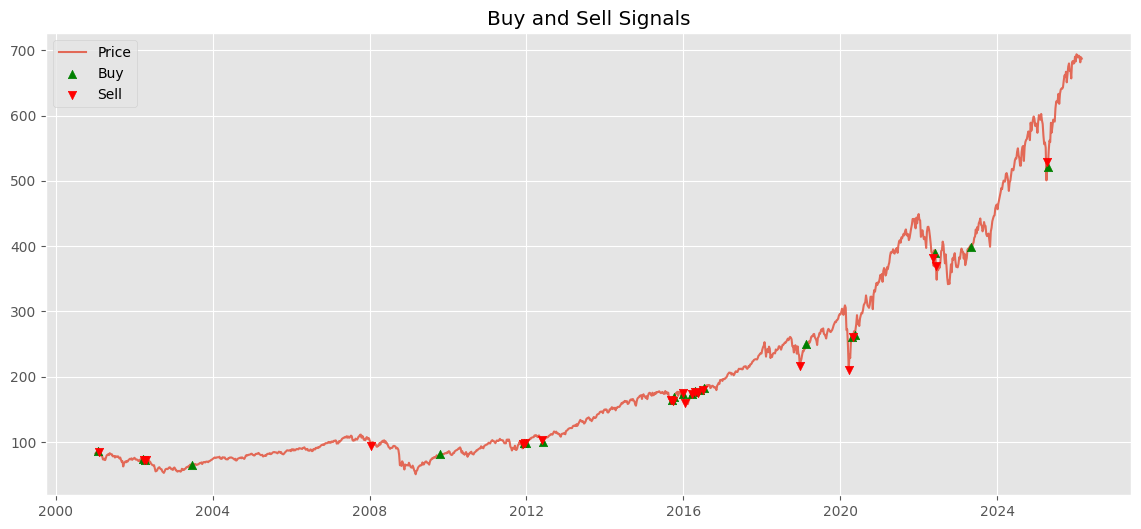

In [11]:
buy_signals = weekly_clean[
    (weekly_clean["Signal"] == 1) &
    (weekly_clean["Signal"].shift(1) == 0)
]

sell_signals = weekly_clean[
    (weekly_clean["Signal"] == 0) &
    (weekly_clean["Signal"].shift(1) == 1)
]

plt.plot(
    weekly_clean.index,
    weekly_clean["Close"],
    label="Price",
    alpha=0.8
)

plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    marker="^",
    color="green",
    label="Buy",
    zorder=3
)

plt.scatter(
    sell_signals.index,
    sell_signals["Close"],
    marker="v",
    color="red",
    label="Sell",
    zorder=3
)

plt.title("Buy and Sell Signals")
plt.legend()
if not IN_COLAB:
  plt.savefig("buy_sell_signals.png")
plt.show()

##### **Evaluating Drawdowns**

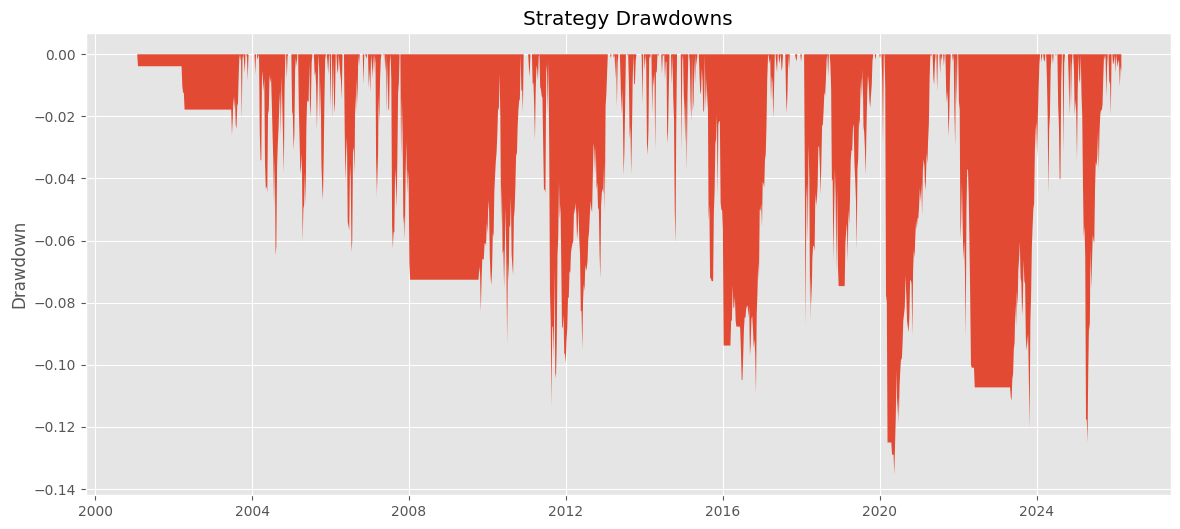

In [12]:
rolling_max = weekly_clean["Cumulative_Strategy"].cummax()
drawdown = weekly_clean["Cumulative_Strategy"] / rolling_max - 1

plt.fill_between(drawdown.index, drawdown, 0)
plt.title("Strategy Drawdowns")
plt.ylabel("Drawdown")
if not IN_COLAB:
  plt.savefig("strategy_drawdowns.png")
plt.show()

##### **Final Performance Comparison**

In [13]:
def performance_metrics(returns):
    ann_return = (1 + returns.mean()) ** 52 - 1
    ann_vol = returns.std() * np.sqrt(52)
    sharpe = ann_return / ann_vol

    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    max_dd = (cumulative / rolling_max - 1).min()

    return ann_return, ann_vol, sharpe, max_dd


metrics = pd.DataFrame(
    [
        performance_metrics(weekly_clean["Returns"]),
        performance_metrics(weekly_clean["Strategy_Returns"])
    ],
    columns=["Annual Return", "Annual Volatility", "Sharpe Ratio", "Max Drawdown"],
    index=["Buy & Hold", "Strategy"]
)

display(metrics)

,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Buy & Hold,0.104153,0.175826,0.592360,-0.546130
Strategy,0.064825,0.085150,0.761299,-0.135246
